# Notebook 8 — Scoring

*SWC ENC 2026 · ephys-pop module*

The whole point of building the recording ourselves: **we know the answer.** On real
data you never see the true spike times, so you can't measure how well a sorter did.
Here we can — and it's the report you always wish you had. We match each sorted unit
to the true neuron it best explains, then count spikes:

- **hit** — a sorted spike within a whisker of a true spike,
- **miss** — a true spike the sorter never found,
- **false positive** — a sorted spike with no true spike nearby,

and turn those into **recall**, **precision**, and an overall **agreement** score.

**In this notebook you will:**
1. **Match** sorted units to true units and count hits/misses/false positives.
2. Read the **per-unit scores** and the **confusion matrix**.
3. **Stress-test** the sorter and watch the scores reveal where it breaks.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import picosort as ps

rec = ps.make_recording(n_units=6, duration_s=20.0, seed=0)
res = ps.run_picosort(rec)
gt = rec.ground_truth
print(f"picosort returned {len(res.spike_times)} spikes in {len(res.template_ids)} units")
print(f"ground truth: {len(gt.spike_times)} spikes in {gt.n_units} units")

picosort returned 398 spikes in 6 units
ground truth: 401 spikes in 6 units


## 1. Match sorted spikes to true spikes

For a matched pair of units, a sorted spike is a **hit** if some true spike falls
within a tolerance (half a millisecond). Counting hits both ways gives recall (of the
true spikes, how many were found) and precision (of the sorted spikes, how many are
real).

<details>
<summary><b>▸ Go deeper: precision, recall, and the matching problem (optional)</b></summary>

With hits (true positives, $\mathrm{TP}$), misses (false negatives, $\mathrm{FN}$),
and false positives ($\mathrm{FP}$), the two scores are

$$\text{recall} = \frac{\mathrm{TP}}{\mathrm{TP}+\mathrm{FN}}
\quad(\text{of the true spikes, the fraction found}),\qquad
\text{precision} = \frac{\mathrm{TP}}{\mathrm{TP}+\mathrm{FP}}
\quad(\text{of the sorted spikes, the fraction real}).$$

They trade off — a sorter that fires constantly has high recall but poor precision —
which is why we report both, and the "agreement"
$\mathrm{TP}/(\mathrm{TP}+\mathrm{FN}+\mathrm{FP})$ that penalises either failure.

But there's a subtlety *before* you can count anything: sorted unit labels are
arbitrary, so **which sorted unit corresponds to which true neuron?** Build the matrix
of hit counts between every (sorted, true) pair, and choose the one-to-one pairing
that maximises the total — a **linear assignment problem**. Trying all pairings is
$k!$, but the **Hungarian algorithm** solves it in $O(k^3)$; that's what
`scipy.optimize.linear_sum_assignment` (inside `ps.match_to_truth`) does. A clean sort
then shows up as a near-diagonal overlap matrix: each sorted unit lights up exactly one
true neuron.
</details>

**Exercise 1** *(~6 min)*. Complete `count_hits`: how many spikes in `a` have a spike in `b`
within `tol` samples. (Sort `b`, use `np.searchsorted` to find each `a`'s nearest
neighbour.)

> **Check / unstuck.** For a well-matched unit, `count_hits(true, sorted)` should be
> almost the whole true train. Stuck? `ps.match_to_truth(...)` does the full job.

In [2]:
def count_hits(a, b, tol):
    if len(a) == 0 or len(b) == 0:
        return 0
    b = np.sort(b)
    idx = np.clip(np.searchsorted(b, a), 1, len(b) - 1)
    nearest = np.minimum(np.abs(b[idx] - a), np.abs(b[idx - 1] - a))
    return int(np.sum(nearest <= tol))

tol = int(0.5e-3 * rec.fs)
# quick sanity check on one unit pairing
t_true0 = gt.spike_times[gt.spike_labels == 0]
best_sorted = max(res.template_ids, key=lambda s: count_hits(t_true0, res.spike_times[res.spike_labels == s], tol))
h = count_hits(t_true0, res.spike_times[res.spike_labels == best_sorted], tol)
print(f"true unit 0 ({len(t_true0)} spikes) best matches sorted unit {best_sorted}: {h} hits")

true unit 0 (66 spikes) best matches sorted unit 2: 66 hits


`ps.match_to_truth` does this for all units at once: it finds the best one-to-one
pairing of sorted units to true units (maximising total hits) and scores each pair.

In [3]:
scores, overlap = ps.match_to_truth(res.spike_times, res.spike_labels,
                                    gt.spike_times, gt.spike_labels, rec.fs)
print(f"{'sorted':>7}{'true':>6}{'recall':>9}{'precision':>11}{'agreement':>11}")
for s in scores:
    print(f"{s.sorted_id:>7}{s.true_id:>6}{s.recall:>9.2f}{s.precision:>11.2f}{s.agreement:>11.2f}")
summary = ps.summary(scores)
print(f"\nmean recall {summary['mean_recall']:.2f} · "
      f"precision {summary['mean_precision']:.2f} · agreement {summary['mean_agreement']:.2f}")

 sorted  true   recall  precision  agreement
      0     2     1.00       1.00       1.00
      1     4     1.00       1.00       1.00
      2     0     1.00       1.00       1.00
      3     5     1.00       1.00       1.00
      4     3     1.00       1.00       1.00
      5     1     1.00       1.00       1.00

mean recall 1.00 · precision 1.00 · agreement 1.00


## 2. The scorecard

Two pictures. The **confusion matrix** shows how sorted units map onto true units — a
clean sort is diagonal (each sorted unit explains exactly one true unit). The **bar
chart** shows recall and precision per unit.

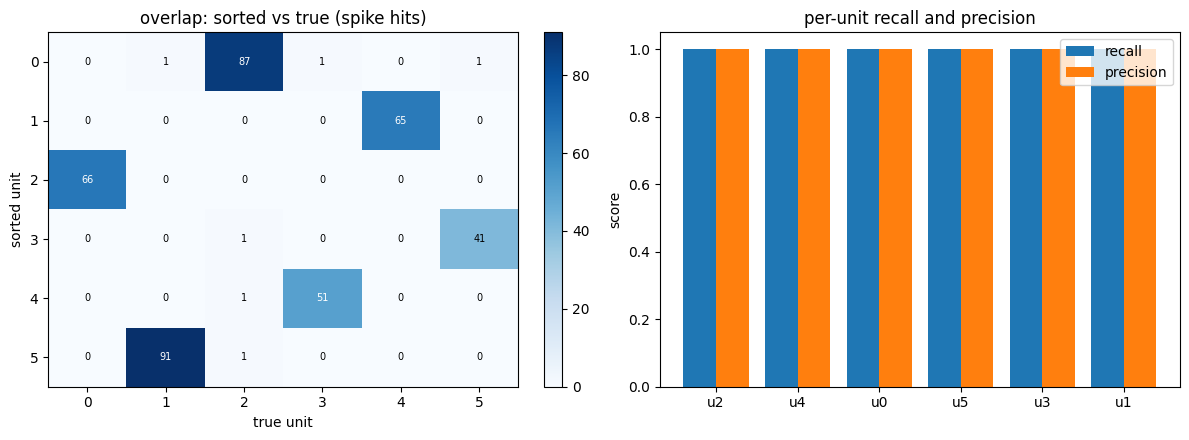

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ps.plotting.plot_confusion(overlap, sorted_ids=res.template_ids,
                           true_ids=np.arange(gt.n_units), ax=axes[0])
x = np.arange(len(scores))
axes[1].bar(x - 0.2, [s.recall for s in scores], 0.4, label="recall")
axes[1].bar(x + 0.2, [s.precision for s in scores], 0.4, label="precision")
axes[1].set_xticks(x); axes[1].set_xticklabels([f"u{s.true_id}" for s in scores])
axes[1].set_ylim(0, 1.05); axes[1].set_ylabel("score"); axes[1].legend()
axes[1].set_title("per-unit recall and precision")
plt.tight_layout(); plt.show()

On this clean recording picosort recovers essentially every spike of every neuron —
a diagonal confusion matrix and scores near 1. That's the sanity check the whole
module was built around: **we put six neurons in, and got six neurons back.** Compare
the sorted and true spike trains directly — they overlay almost perfectly:

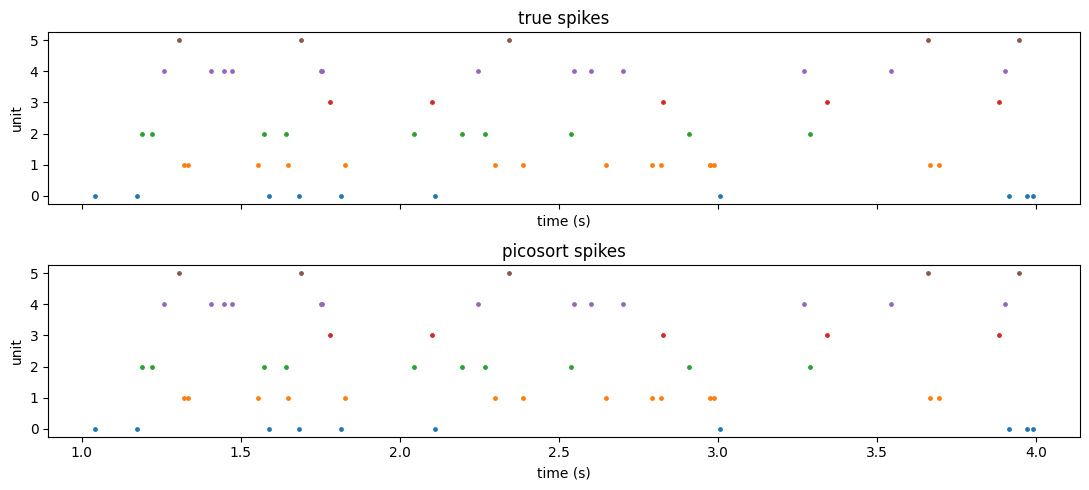

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
ps.plotting.plot_raster(gt.spike_times, gt.spike_labels, rec.fs, t0=1.0, t1=4.0,
                        ax=axes[0], title="true spikes")
# relabel sorted units by their matched true id for a fair overlay
match = {s.sorted_id: s.true_id for s in scores}
mapped = np.array([match.get(l, l) for l in res.spike_labels])
ps.plotting.plot_raster(res.spike_times, mapped, rec.fs, t0=1.0, t1=4.0,
                        ax=axes[1], title="picosort spikes")
plt.tight_layout(); plt.show()

## 3. Stress test: where does it break?

A perfect score means the *problem* was easy enough, not that sorting is always easy.
Turn up the **noise** and watch the scores fall — and notice *which* units fail first.
The smallest-amplitude neurons disappear into the noise soonest, exactly as on real
probes, where low-amplitude units are the hardest to isolate.

**Exercise 2** *(~5 min)*. Sweep the noise level, sort each recording, and plot mean recall
vs noise. It should decline as the noise rises.

> **Check / unstuck.** Recall stays high at low noise and drops as `noise_sd` grows
> past the weaker units' amplitudes. Stuck? see the solution.

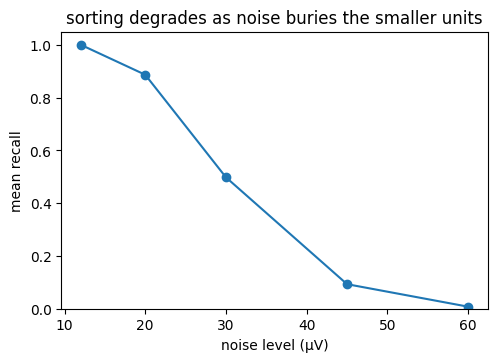

In [6]:
noise_levels = [12, 20, 30, 45, 60]
recalls = []
for nsd in noise_levels:
    r = ps.make_recording(n_units=6, duration_s=20.0, noise_sd=nsd, seed=0)
    res_n = ps.run_picosort(r)
    sc, _ = ps.match_to_truth(res_n.spike_times, res_n.spike_labels,
                              r.ground_truth.spike_times, r.ground_truth.spike_labels, r.fs)
    recalls.append(ps.summary(sc)["mean_recall"])

plt.figure(figsize=(5.5, 3.6))
plt.plot(noise_levels, recalls, "o-")
plt.xlabel("noise level (µV)"); plt.ylabel("mean recall"); plt.ylim(0, 1.05)
plt.title("sorting degrades as noise buries the smaller units"); plt.show()

## Wrap-up — the whole pipeline

You built **picosort** end to end and graded it against a truth you controlled:

**preprocess** (high-pass · CAR · whiten) → **detect** → **features** (depth,
amplitude, PCA) → **cluster** (Gaussian mixture) → **templates** → **matching
pursuit** → **merge/QC** → **score**.

Every stage was checked against ground truth — the spine of the module. A real sorter
like Kilosort adds the pieces we set aside: **drift correction** (the brain moves
relative to the probe), hundreds of channels and thousands of units, GPU-scale
matching pursuit, and automated merge/split. But the ideas are exactly the ones you
just implemented. Next time you run Kilosort and stare at its output, you'll know what
every step is doing — and why a low-amplitude unit near the noise is the one to
double-check.